## Environment Setup

In [14]:
import re
import string
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Mount G-Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## File Registry & Model Mapping

In [16]:
MODEL_FILES = {
    "gpt-4o-mini": sorted(glob.glob("/content/drive/MyDrive/MS-LJMU/AllModelRAGEvalResults/gpt-4o-mini-gt-evaluation_*.csv")),
    "gpt-5-mini-2025": sorted(glob.glob("/content/drive/MyDrive/MS-LJMU/AllModelRAGEvalResults/gpt-5-mini-2025-08-07-gt-evaluation_*.csv")),
    "gpt-5.2-2025": sorted(glob.glob("/content/drive/MyDrive/MS-LJMU/AllModelRAGEvalResults/gpt-5.2-2025-12-11-gt-evaluation_*.csv")),
    "llama-3.1-8b": sorted(glob.glob("/content/drive/MyDrive/MS-LJMU/AllModelRAGEvalResults/llama-3.1-8b-gt-evaluation_*.csv")),
    "llama-3.3-70b": sorted(glob.glob("/content/drive/MyDrive/MS-LJMU/AllModelRAGEvalResults/llama-3.3-70b-gt-evaluation_*.csv")),
}

for model, files in MODEL_FILES.items():
    print(model, len(files))

gpt-4o-mini 5
gpt-5-mini-2025 5
gpt-5.2-2025 5
llama-3.1-8b 5
llama-3.3-70b 5


## Load & Combine Runs (Run-Aware DataFrame)

In [17]:
def load_model_runs(model_name, file_list):
    dfs = []
    for run_id, file in enumerate(file_list, start=1):
        df = pd.read_csv(file)
        df["model"] = model_name
        df["run"] = run_id
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [18]:
all_dfs = []
for model, files in MODEL_FILES.items():
    all_dfs.append(load_model_runs(model, files))

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.head()

,question,ground_truth_answer,source_document,supporting_context,topic,context_used,llm_response,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score,model,run
0,Why do low levels of DC-SIGNR enhance Mother t...,"in placenta containing low levels of DC-SIGNR,...",COVID-QA_MASTER,Functional Genetic Variants in DC-SIGNR Are As...,transmission,Low levels of DC-SIGNR in the placenta allow H...,Low levels of DC-SIGNR enhance Mother to Child...,0.089039,0.323232,0.907497,1.0,1.0,1.000,0.203518,gpt-4o-mini,1
1,What is the best way to counteract misinformat...,One strategy we've used in Baltimore is buildi...,COUGH_FAQ_BANK,One strategy we've used in Baltimore is buildi...,myths,To counteract misinformation about COVID-19 in...,The best way to counteract misinformation and ...,0.000000,0.168675,0.812027,1.0,1.0,1.000,0.315472,gpt-4o-mini,1
2,What are the symptoms?,Most people will have mild effects from the vi...,COUGH_FAQ_BANK,Most people will have mild effects from the vi...,symptoms,"Symptoms include: fever or chills, cough, shor...","The symptoms include: fever or chills, cough, ...",0.049055,0.492063,0.781250,1.0,1.0,0.200,0.661059,gpt-4o-mini,1
3,What plays the crucial role in the Mother to C...,DC-SIGNR plays a crucial role in MTCT of HIV-1...,COVID-QA_MASTER,Functional Genetic Variants in DC-SIGNR Are As...,transmission,DC-SIGNR plays a crucial role in Mother to Chi...,DC-SIGNR plays a crucial role in Mother to Chi...,0.182701,0.555556,0.716214,1.0,1.0,1.000,0.219430,gpt-4o-mini,1
4,Should vaccination of HBV-exposed infants cont...,"Yes. Hepatitis B vaccination of all infants, e...",COUGH_FAQ_BANK,"Yes. Hepatitis B vaccination of all infants, e...",vaccination,Vaccination of HBV-exposed infants should cont...,"Yes, vaccination of HBV-exposed infants should...",0.000000,0.080460,1.000000,1.0,1.0,0.125,0.457329,gpt-4o-mini,1


In [19]:
df_all.shape

(1250, 16)

In [20]:
df_all.columns

Index(['question', 'ground_truth_answer', 'source_document',
       'supporting_context', 'topic', 'context_used', 'llm_response', 'bleu',
       'rougeL', 'answer_relevancy', 'faithfulness', 'context_precision',
       'context_recall', 'summarization_score', 'model', 'run'],
      dtype='object')

## Exact Match and F1-score Computation

### Normalization Function

In [21]:


def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = "".join(ch for ch in text if ch not in string.punctuation)
    text = " ".join(text.split())
    return text

### Exact Match (EM) Computation

Definition
EM = 1 if normalized prediction == normalized ground truth, else 0.

In [22]:
def compute_exact_match(prediction, ground_truth):
    return int(normalize_text(prediction) == normalize_text(ground_truth))

#### Apply to DataFrame

In [23]:
df_all.columns

Index(['question', 'ground_truth_answer', 'source_document',
       'supporting_context', 'topic', 'context_used', 'llm_response', 'bleu',
       'rougeL', 'answer_relevancy', 'faithfulness', 'context_precision',
       'context_recall', 'summarization_score', 'model', 'run'],
      dtype='object')

In [24]:
df_all["exact_match"] = df_all.apply(
    lambda row: compute_exact_match(
        row["llm_response"],
        row["ground_truth_answer"]
    ),
    axis=1
)

### Token-level F1 Computation (SQuAD-Style)

F1 = harmonic mean of token precision and recall.

In [25]:
from collections import Counter

def compute_f1(prediction, ground_truth):
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()

    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return 0.0

    common_tokens = Counter(pred_tokens) & Counter(gt_tokens)
    num_common = sum(common_tokens.values())

    if num_common == 0:
        return 0.0

    precision = num_common / len(pred_tokens)
    recall = num_common / len(gt_tokens)

    return 2 * precision * recall / (precision + recall)

#### Apply to DataFrame

In [26]:
df_all["f1"] = df_all.apply(
    lambda row: compute_f1(
        row["llm_response"],
        row["ground_truth_answer"]
    ),
    axis=1
)

## Metric Groups

In [27]:
PRIMARY_ACCURACY = ["exact_match", "f1"]

SEMANTIC_QUALITY = [
    "answer_relevancy",
    "faithfulness",
    "summarization_score"
]

RETRIEVAL_QUALITY = [
    "context_precision",
    "context_recall"
]

OVERLAP_METRICS = [
    "bleu",
    "rougeL"
]

ALL_METRICS = PRIMARY_ACCURACY + SEMANTIC_QUALITY + RETRIEVAL_QUALITY + OVERLAP_METRICS

In [28]:
print(f"Total metrics: {len(ALL_METRICS)}")

Total metrics: 9


## Model-wise Aggregate Performance (Mean ± Std)

In [29]:
summary = (
    df_all
    .groupby("model")[ALL_METRICS]
    .agg(["mean", "std"])
    .round(4)
)

summary

exact_match           f1         answer_relevancy          \
                       mean  std    mean     std             mean     std   
model                                                                       
gpt-4o-mini             0.0  0.0  0.3128  0.1895           0.7471  0.3023   
gpt-5-mini-2025         0.0  0.0  0.3028  0.1681           0.5400  0.3943   
gpt-5.2-2025            0.0  0.0  0.3219  0.1755           0.6577  0.3613   
llama-3.1-8b            0.0  0.0  0.3252  0.1771           0.7140  0.2800   
llama-3.3-70b           0.0  0.0  0.3058  0.1781           0.7009  0.3503   

                faithfulness         summarization_score          \
                        mean     std                mean     std   
model                                                              
gpt-4o-mini           0.9046  0.2575              0.3594  0.1632   
gpt-5-mini-2025       0.9372  0.1119              0.2594  0.1834   
gpt-5.2-2025          0.9253  0.1634              0.2933  0.1801   
llama-3.1-8b          0.9208  0.1878              0.3614  0.1626   
llama-3.3-70b         0.9330  0.1726              0.3515  0.1507   

                context_precision         context_recall            bleu  \
                             mean     std           mean     std    mean   
model                                                                      
gpt-4o-mini                 0.836  0.3710         0.6918  0.3757  0.0638   
gpt-5-mini-2025             0.820  0.3850         0.6863  0.3779  0.0601   
gpt-5.2-2025                0.824  0.3816         0.6918  0.3750  0.0623   
llama-3.1-8b                0.816  0.3883         0.7054  0.3698  0.0767   
llama-3.3-70b               0.820  0.3850         0.6920  0.3758  0.0635   

                         rougeL          
                    std    mean     std  
model                                    
gpt-4o-mini      0.0916  0.2480  0.1606  
gpt-5-mini-2025  0.0696  0.2250  0.1279  
gpt-5.2-2025     0.0779  0.2514  0.1477  
llama-3.1-8b     0.1065  0.2632  0.1539  
llama-3.3-70b    0.0851  0.2417  0.1434

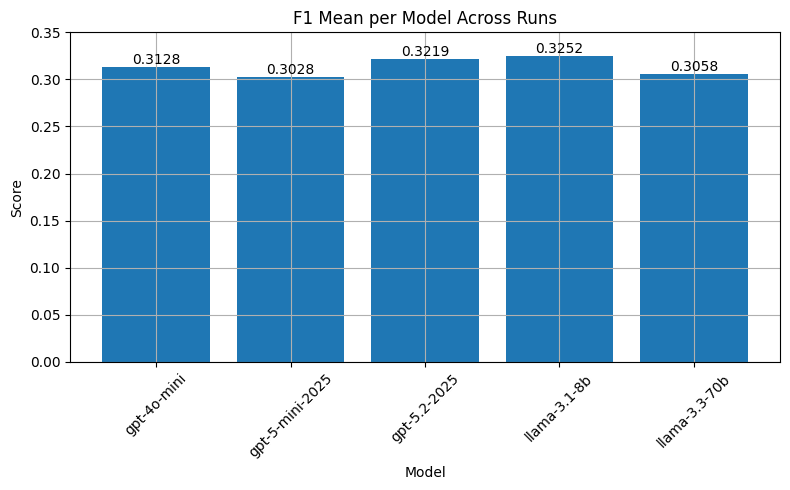

In [30]:
# Extracted F1 mean values from table
models = [
    "gpt-4o-mini",
    "gpt-5-mini-2025",
    "gpt-5.2-2025",
    "llama-3.1-8b",
    "llama-3.3-70b"
]

f1_means = [0.3128, 0.3028, 0.3219, 0.3252, 0.3058]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(models, f1_means)

plt.title("F1 Mean per Model Across Runs")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.ylim(0, 0.35)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

## Accuracy Analysis

### Exact Match Distribution (Boxplot)

<Figure size 800x500 with 0 Axes>

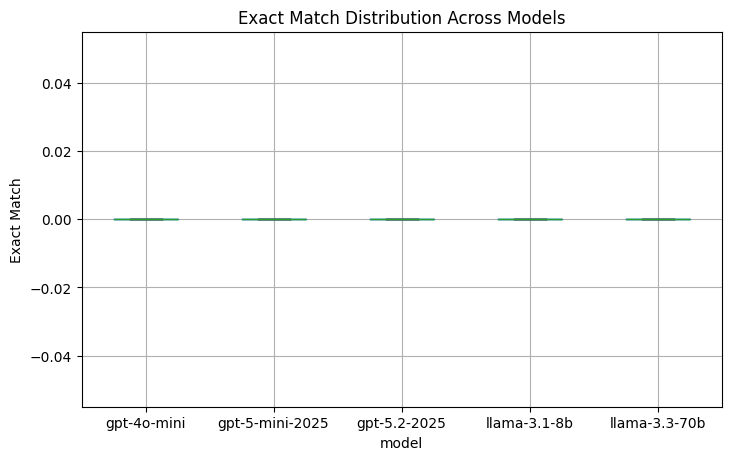

In [31]:
plt.figure()
df_all.boxplot(column="exact_match", by="model")
plt.title("Exact Match Distribution Across Models")
plt.suptitle("")
plt.ylabel("Exact Match")
plt.show()

### F1 Score Distribution (Boxplot)

<Figure size 800x500 with 0 Axes>

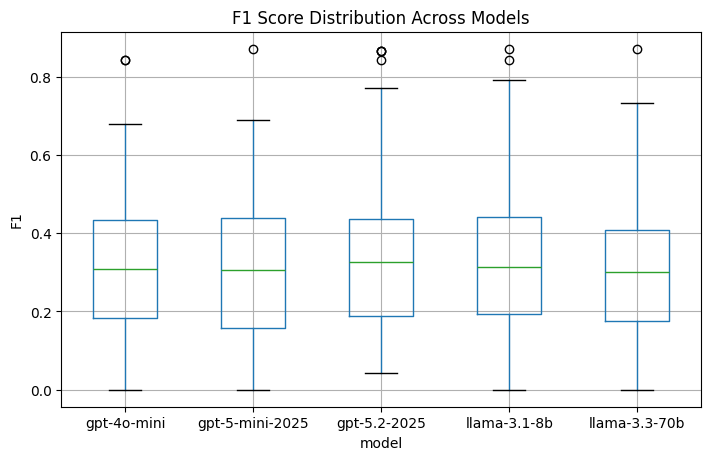

In [32]:
plt.figure()
df_all.boxplot(column="f1", by="model")
plt.title("F1 Score Distribution Across Models")
plt.suptitle("")
plt.ylabel("F1")
plt.show()

## Run-to-Run Stability Analysis

### Mean Accuracy per Run

In [33]:
run_stats = (
    df_all
    .groupby(["model", "run"])[PRIMARY_ACCURACY]
    .mean()
    .reset_index()
)

run_stats

,model,run,exact_match,f1
0,gpt-4o-mini,1,0.0,0.313155
1,gpt-4o-mini,2,0.0,0.301045
2,gpt-4o-mini,3,0.0,0.317182
3,gpt-4o-mini,4,0.0,0.314225
4,gpt-4o-mini,5,0.0,0.318463
5,gpt-5-mini-2025,1,0.0,0.314589
6,gpt-5-mini-2025,2,0.0,0.295951
7,gpt-5-mini-2025,3,0.0,0.303092
8,gpt-5-mini-2025,4,0.0,0.299726
9,gpt-5-mini-2025,5,0.0,0.300494


### Error Bars (Mean ± Std Across Runs)

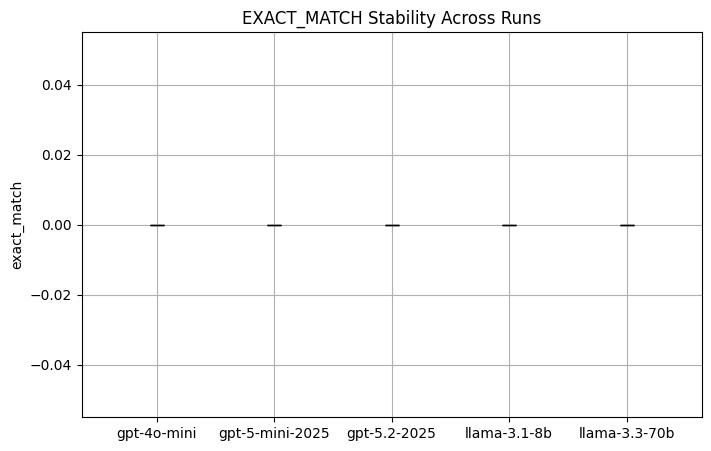

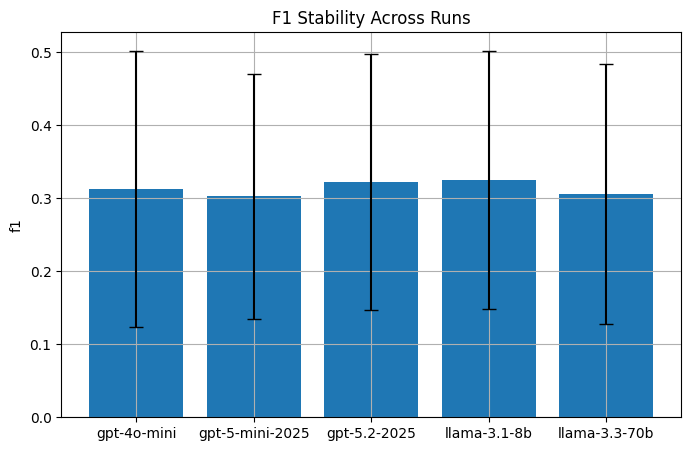

In [34]:
for metric in PRIMARY_ACCURACY:
    means = df_all.groupby("model")[metric].mean()
    stds = df_all.groupby("model")[metric].std()

    plt.figure()
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.title(f"{metric.upper()} Stability Across Runs")
    plt.ylabel(metric)
    plt.show()

## Question-Level Difficulty Analysis (Explainability)

### Difficulty Buckets Using EM

In [35]:
question_perf = (
    df_all
    .groupby("question")[PRIMARY_ACCURACY]
    .mean()
)

# Check if all exact_match values are the same
if question_perf["exact_match"].nunique() == 1:
    # If all exact_match scores are the same, we cannot create distinct buckets.
    # Assign a single label. Assuming 0.0 EM implies 'Hard' difficulty.
    question_perf["difficulty"] = "Hard"
else:
    question_perf["difficulty"] = pd.qcut(
        question_perf["exact_match"],
        q=3,
        labels=["Hard", "Medium", "Easy"],
        duplicates='drop'
    )

question_perf["difficulty"].value_counts()

,count
difficulty,
Hard,50


### Model Performance on Hard Questions

In [36]:
hard_questions = question_perf[
    question_perf["difficulty"] == "Hard"
].index

df_all[df_all["question"].isin(hard_questions)] \
    .groupby("model")["exact_match"] \
    .mean()

,exact_match
model,
gpt-4o-mini,0.0
gpt-5-mini-2025,0.0
gpt-5.2-2025,0.0
llama-3.1-8b,0.0
llama-3.3-70b,0.0


## Retrieval Quality vs Answer Quality

### Context Precision vs Faithfulness

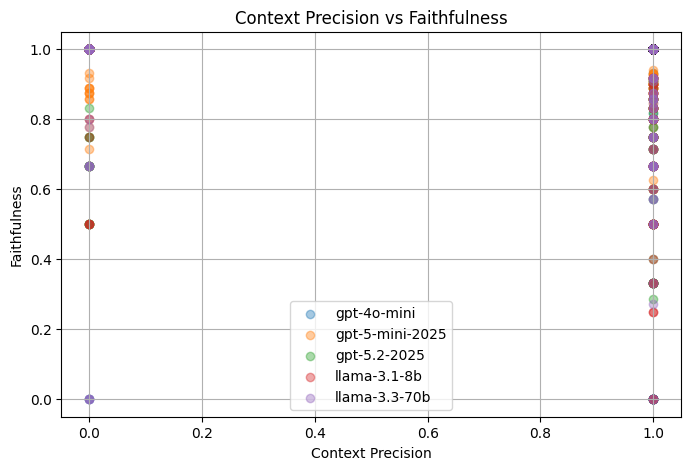

In [37]:
plt.figure()
for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.scatter(
        subset["context_precision"],
        subset["faithfulness"],
        alpha=0.4,
        label=model
    )

plt.xlabel("Context Precision")
plt.ylabel("Faithfulness")
plt.title("Context Precision vs Faithfulness")
plt.legend()
plt.show()

### Context Recall vs Exact Match

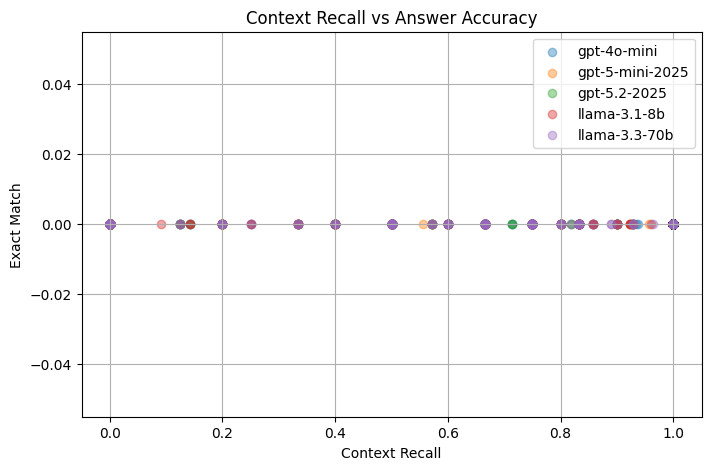

In [38]:
plt.figure()
for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.scatter(
        subset["context_recall"],
        subset["exact_match"],
        alpha=0.4,
        label=model
    )

plt.xlabel("Context Recall")
plt.ylabel("Exact Match")
plt.title("Context Recall vs Answer Accuracy")
plt.legend()
plt.show()

### Correlation Matrix (Numerical Evidence)

In [39]:
corr = df_all[
    PRIMARY_ACCURACY +
    RETRIEVAL_QUALITY +
    SEMANTIC_QUALITY
].corr().round(3)

corr

,exact_match,f1,context_precision,context_recall,answer_relevancy,faithfulness,summarization_score
exact_match,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f1,NaN,1.000,0.464,0.433,0.177,0.208,0.152
context_precision,NaN,0.464,1.000,0.684,0.082,0.004,0.168
context_recall,NaN,0.433,0.684,1.000,0.066,-0.012,0.074
answer_relevancy,NaN,0.177,0.082,0.066,1.000,0.264,-0.036
faithfulness,NaN,0.208,0.004,-0.012,0.264,1.000,-0.032
summarization_score,NaN,0.152,0.168,0.074,-0.036,-0.032,1.000


## Semantic Metrics Analysis (Supporting Evidence)

### Faithfulness Distribution

<Figure size 800x500 with 0 Axes>

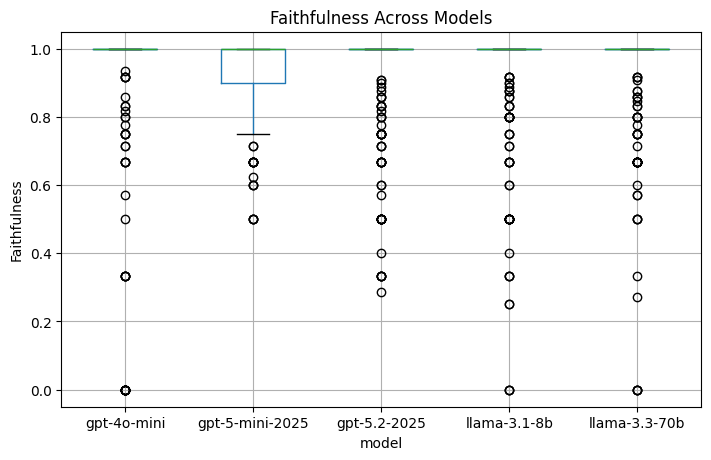

In [40]:
plt.figure()
df_all.boxplot(column="faithfulness", by="model")
plt.title("Faithfulness Across Models")
plt.suptitle("")
plt.ylabel("Faithfulness")
plt.show()

### Answer Relevancy vs F1

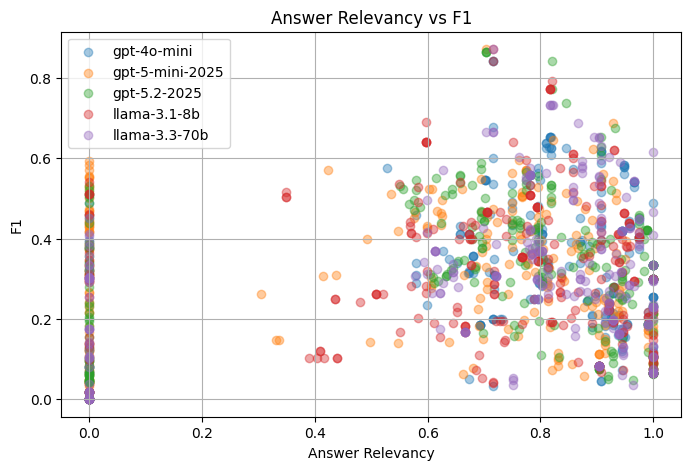

In [41]:
plt.figure()
for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.scatter(
        subset["answer_relevancy"],
        subset["f1"],
        alpha=0.4,
        label=model
    )

plt.xlabel("Answer Relevancy")
plt.ylabel("F1")
plt.title("Answer Relevancy vs F1")
plt.legend()
plt.show()

## Radar Chart – Overall Model Comparison

In [42]:
def radar_chart(data, metrics):
    labels = metrics
    angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
    angles += angles[:1]

    plt.figure()
    ax = plt.subplot(111, polar=True)

    for model in data.index:
        values = data.loc[model, metrics].values.tolist()
        values += values[:1]
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.title("Overall RAG Performance Comparison")
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.show()

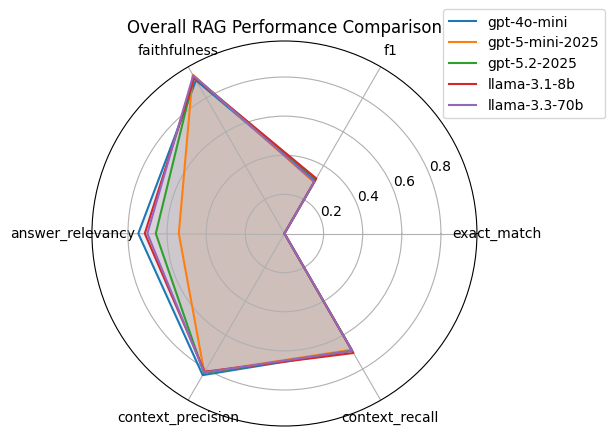

In [43]:
mean_scores = df_all.groupby("model")[ALL_METRICS].mean()

radar_chart(
    mean_scores,
    ["exact_match", "f1", "faithfulness",
     "answer_relevancy", "context_precision", "context_recall"]
)

## Statistical Significance Testing

In [44]:
from scipy.stats import ttest_rel

models = df_all["model"].unique()

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        m1, m2 = models[i], models[j]
        s1 = df_all[df_all["model"] == m1].groupby("question")["f1"].mean()
        s2 = df_all[df_all["model"] == m2].groupby("question")["f1"].mean()

        stat, p = ttest_rel(s1, s2)
        print(f"{m1} vs {m2} | F1 p-value = {p:.5f}")

gpt-4o-mini vs gpt-5-mini-2025 | F1 p-value = 0.54132
gpt-4o-mini vs gpt-5.2-2025 | F1 p-value = 0.51556
gpt-4o-mini vs llama-3.1-8b | F1 p-value = 0.25264
gpt-4o-mini vs llama-3.3-70b | F1 p-value = 0.41573
gpt-5-mini-2025 vs gpt-5.2-2025 | F1 p-value = 0.11351
gpt-5-mini-2025 vs llama-3.1-8b | F1 p-value = 0.12360
gpt-5-mini-2025 vs llama-3.3-70b | F1 p-value = 0.82628
gpt-5.2-2025 vs llama-3.1-8b | F1 p-value = 0.80871
gpt-5.2-2025 vs llama-3.3-70b | F1 p-value = 0.17268
llama-3.1-8b vs llama-3.3-70b | F1 p-value = 0.05251


## Common metrics and Vizulaization for analysis

### Compute mean metrics per model across 5 runs?

In [45]:
# List all evaluation metrics
metrics = [
    'bleu', 'rougeL',
    'answer_relevancy', 'faithfulness',
    'context_precision', 'context_recall',
    'summarization_score'
]

# Mean per model across runs
mean_metrics = df_all.groupby('model')[metrics].mean().reset_index()

mean_metrics

,model,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score
0,gpt-4o-mini,0.063791,0.247988,0.747143,0.904612,0.836,0.691779,0.359369
1,gpt-5-mini-2025,0.060065,0.224962,0.539998,0.937208,0.820,0.686311,0.259432
2,gpt-5.2-2025,0.062272,0.251428,0.657659,0.925265,0.824,0.691843,0.293285
3,llama-3.1-8b,0.076664,0.263179,0.713969,0.920827,0.816,0.705409,0.361427
4,llama-3.3-70b,0.063541,0.241749,0.700869,0.933004,0.820,0.692003,0.351481


### Compute Standard Deviation and Variance Across Runs

#### Standard Deviation

In [46]:
std_metrics = df_all.groupby('model')[metrics].std().reset_index()
std_metrics

,model,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score
0,gpt-4o-mini,0.091575,0.160575,0.302294,0.257494,0.371018,0.375725,0.163182
1,gpt-5-mini-2025,0.069594,0.127862,0.394322,0.111908,0.384958,0.377884,0.183363
2,gpt-5.2-2025,0.077900,0.147680,0.361319,0.163443,0.381584,0.374987,0.180089
3,llama-3.1-8b,0.106532,0.153924,0.279990,0.187765,0.388261,0.369839,0.162580
4,llama-3.3-70b,0.085086,0.143412,0.350332,0.172594,0.384958,0.375768,0.150712


#### Variance

In [47]:
var_metrics = df_all.groupby('model')[metrics].var().reset_index()
var_metrics

,model,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score
0,gpt-4o-mini,0.008386,0.025784,0.091382,0.066303,0.137655,0.141169,0.026628
1,gpt-5-mini-2025,0.004843,0.016349,0.155490,0.012523,0.148193,0.142796,0.033622
2,gpt-5.2-2025,0.006068,0.021809,0.130552,0.026714,0.145606,0.140615,0.032432
3,llama-3.1-8b,0.011349,0.023693,0.078394,0.035256,0.150747,0.136781,0.026432
4,llama-3.3-70b,0.007240,0.020567,0.122733,0.029789,0.148193,0.141202,0.022714


### Per-Metric Ranking Comparison

In [48]:
# Rank models per metric (higher = better)
rank_df = mean_metrics.set_index('model').rank(ascending=False)
rank_df

,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score
model,,,,,,,
gpt-4o-mini,2.0,3.0,1.0,5.0,1.0,4.0,2.0
gpt-5-mini-2025,5.0,5.0,5.0,1.0,3.5,5.0,5.0
gpt-5.2-2025,4.0,2.0,4.0,3.0,2.0,3.0,4.0
llama-3.1-8b,1.0,1.0,2.0,4.0,5.0,1.0,1.0
llama-3.3-70b,3.0,4.0,3.0,2.0,3.5,2.0,3.0


In [49]:
rank_df_dense = mean_metrics.set_index('model').rank(
    ascending=False,
    method='dense'
)
rank_df_dense

,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score
model,,,,,,,
gpt-4o-mini,2.0,3.0,1.0,5.0,1.0,4.0,2.0
gpt-5-mini-2025,5.0,5.0,5.0,1.0,3.0,5.0,5.0
gpt-5.2-2025,4.0,2.0,4.0,3.0,2.0,3.0,4.0
llama-3.1-8b,1.0,1.0,2.0,4.0,4.0,1.0,1.0
llama-3.3-70b,3.0,4.0,3.0,2.0,3.0,2.0,3.0


In [78]:
# ranking table

ranking = mean_metrics.copy()

for metric in metrics:
    ranking[metric + '_rank'] = ranking[metric].rank(ascending=False)

ranking

,model,bleu,rougeL,answer_relevancy,faithfulness,context_precision,context_recall,summarization_score,bleu_rank,rougeL_rank,answer_relevancy_rank,faithfulness_rank,context_precision_rank,context_recall_rank,summarization_score_rank
0,gpt-4o-mini,0.063791,0.247988,0.747143,0.904612,0.836,0.691779,0.359369,2.0,3.0,1.0,5.0,1.0,4.0,2.0
1,gpt-5-mini-2025,0.060065,0.224962,0.539998,0.937208,0.820,0.686311,0.259432,5.0,5.0,5.0,1.0,3.5,5.0,5.0
2,gpt-5.2-2025,0.062272,0.251428,0.657659,0.925265,0.824,0.691843,0.293285,4.0,2.0,4.0,3.0,2.0,3.0,4.0
3,llama-3.1-8b,0.076664,0.263179,0.713969,0.920827,0.816,0.705409,0.361427,1.0,1.0,2.0,4.0,5.0,1.0,1.0
4,llama-3.3-70b,0.063541,0.241749,0.700869,0.933004,0.820,0.692003,0.351481,3.0,4.0,3.0,2.0,3.5,2.0,3.0


In [80]:
ranking.columns

Index(['model', 'bleu', 'rougeL', 'answer_relevancy', 'faithfulness',
       'context_precision', 'context_recall', 'summarization_score',
       'bleu_rank', 'rougeL_rank', 'answer_relevancy_rank',
       'faithfulness_rank', 'context_precision_rank', 'context_recall_rank',
       'summarization_score_rank'],
      dtype='object')

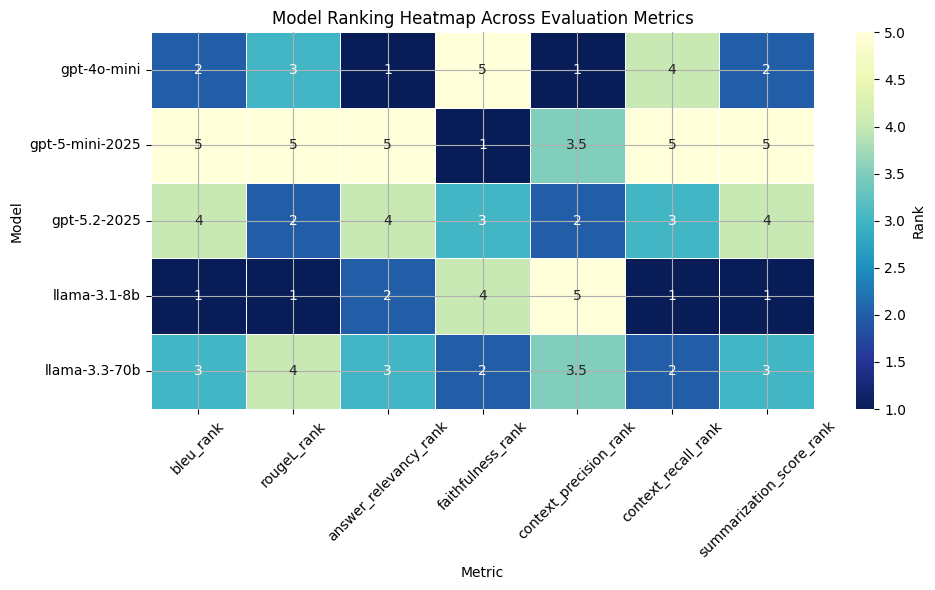

In [81]:
import seaborn as sns

# Copy dataframe (assuming your dataframe is called ranking)
rank_df = ranking.copy()

# Set model as index
rank_df = rank_df.set_index("model")

# Select only rank columns
rank_columns = [col for col in rank_df.columns if col.endswith("_rank")]

rank_matrix = rank_df[rank_columns]

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    rank_matrix,
    annot=True,
    cmap="YlGnBu_r",   # reversed so rank 1 looks darker/better
    linewidths=0.5,
    cbar_kws={'label': 'Rank'}
)

plt.title("Model Ranking Heatmap Across Evaluation Metrics")
plt.ylabel("Model")
plt.xlabel("Metric")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Generate Visualisations

#### Bar Chart – Mean Comparison

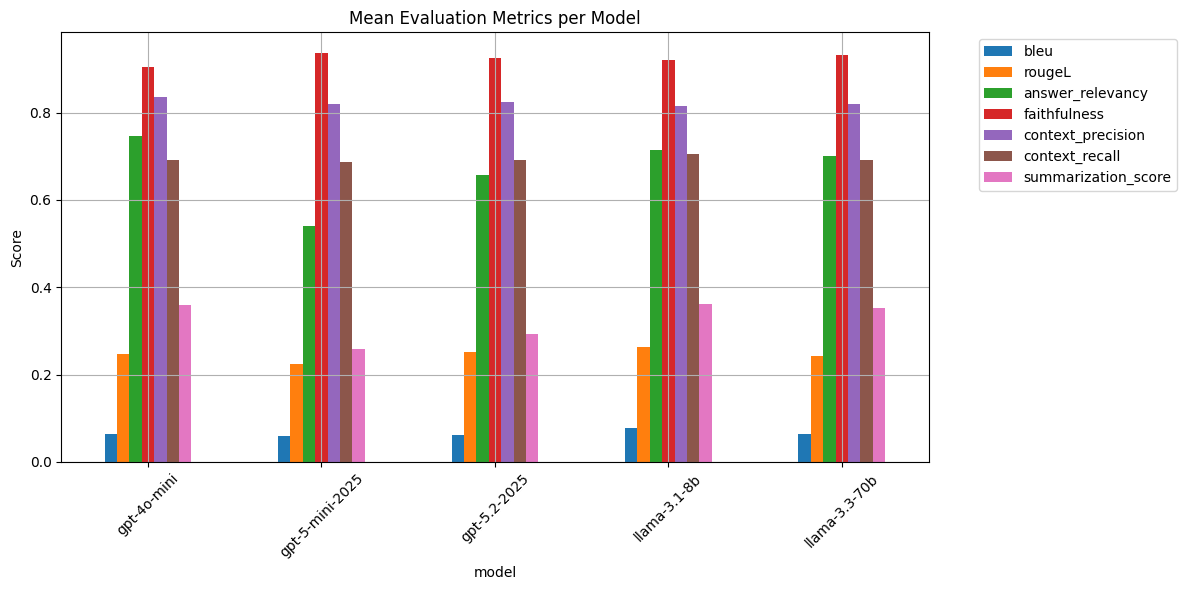

In [51]:
mean_metrics.set_index('model')[metrics].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Mean Evaluation Metrics per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [52]:
# List all evaluation metrics
bleu_rougel_metrics = [
    'bleu', 'rougeL',
]

# Mean per model across runs
bleu_and_rougel_mean = df_all.groupby('model')[bleu_rougel_metrics].mean().reset_index()

bleu_and_rougel_mean

,model,bleu,rougeL
0,gpt-4o-mini,0.063791,0.247988
1,gpt-5-mini-2025,0.060065,0.224962
2,gpt-5.2-2025,0.062272,0.251428
3,llama-3.1-8b,0.076664,0.263179
4,llama-3.3-70b,0.063541,0.241749


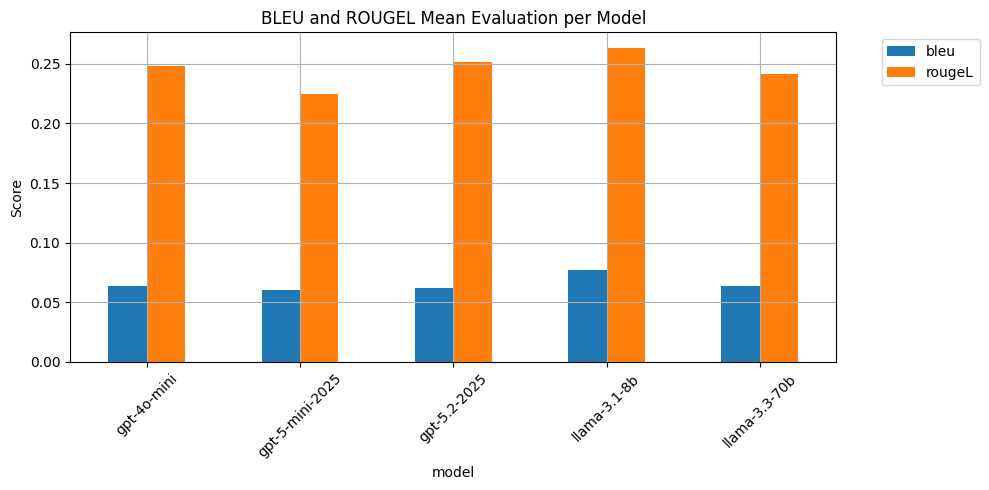

In [53]:
bleu_and_rougel_mean.set_index('model')[bleu_rougel_metrics].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("BLEU and ROUGEL Mean Evaluation per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [54]:
# List all evaluation metrics
retrieval_grounded_metrics = [
    'answer_relevancy', 'faithfulness',
    'context_precision', 'context_recall',
]

# Mean per model across runs
retrieval_grounded_metrics_mean = df_all.groupby('model')[retrieval_grounded_metrics].mean().reset_index()

retrieval_grounded_metrics_mean

,model,answer_relevancy,faithfulness,context_precision,context_recall
0,gpt-4o-mini,0.747143,0.904612,0.836,0.691779
1,gpt-5-mini-2025,0.539998,0.937208,0.820,0.686311
2,gpt-5.2-2025,0.657659,0.925265,0.824,0.691843
3,llama-3.1-8b,0.713969,0.920827,0.816,0.705409
4,llama-3.3-70b,0.700869,0.933004,0.820,0.692003


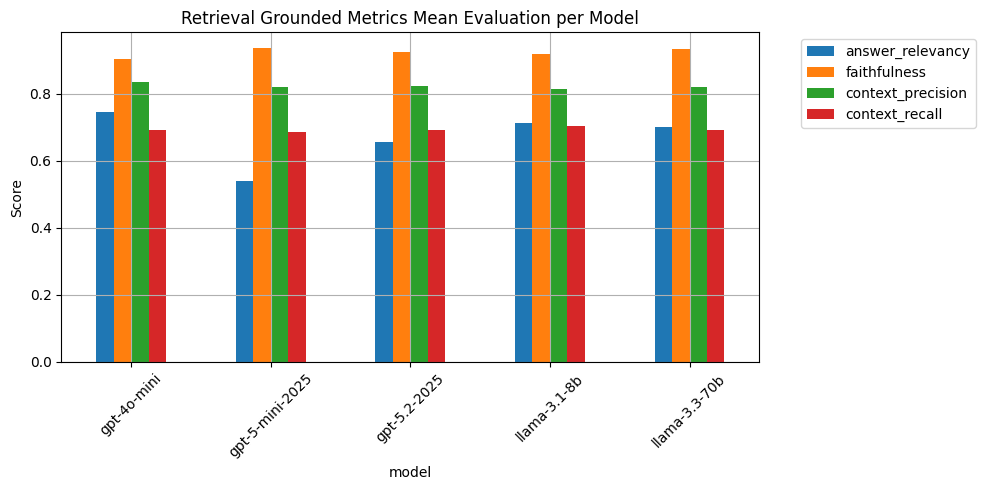

In [55]:
retrieval_grounded_metrics_mean.set_index('model')[retrieval_grounded_metrics].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Retrieval Grounded Metrics Mean Evaluation per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [65]:
# List all evaluation metrics
faithul_metrics = [
    'faithfulness'
]

# Mean per model across runs
mean_faithful_metrics = df_all.groupby('model')[faithul_metrics].mean().reset_index()

mean_faithful_metrics

,model,faithfulness
0,gpt-4o-mini,0.904612
1,gpt-5-mini-2025,0.937208
2,gpt-5.2-2025,0.925265
3,llama-3.1-8b,0.920827
4,llama-3.3-70b,0.933004


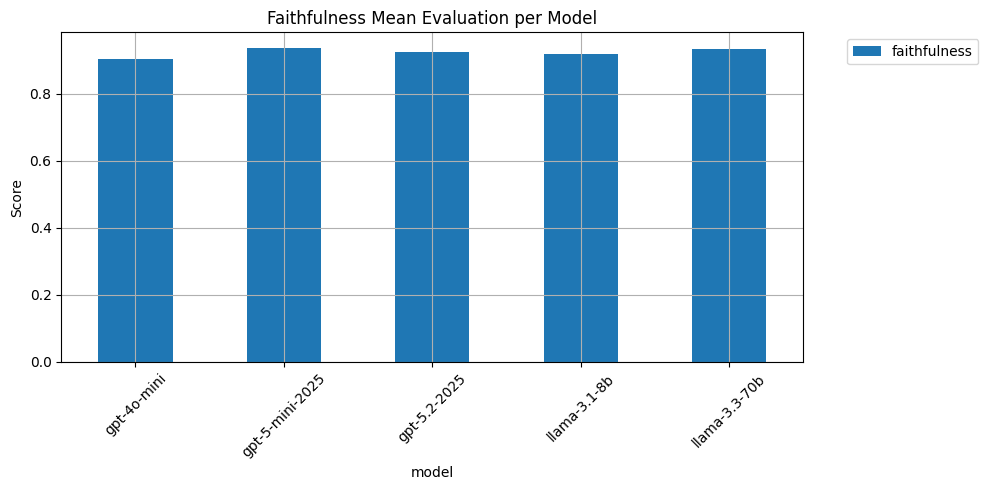

In [67]:
mean_faithful_metrics.set_index('model')[faithul_metrics].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Faithfulness Mean Evaluation per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [68]:
# List all evaluation metrics
precision_recall_metrics = [
    'context_precision', 'context_recall'
]

# Mean per model across runs
mean_pre_recall_metrics = df_all.groupby('model')[precision_recall_metrics].mean().reset_index()

mean_pre_recall_metrics

,model,context_precision,context_recall
0,gpt-4o-mini,0.836,0.691779
1,gpt-5-mini-2025,0.820,0.686311
2,gpt-5.2-2025,0.824,0.691843
3,llama-3.1-8b,0.816,0.705409
4,llama-3.3-70b,0.820,0.692003


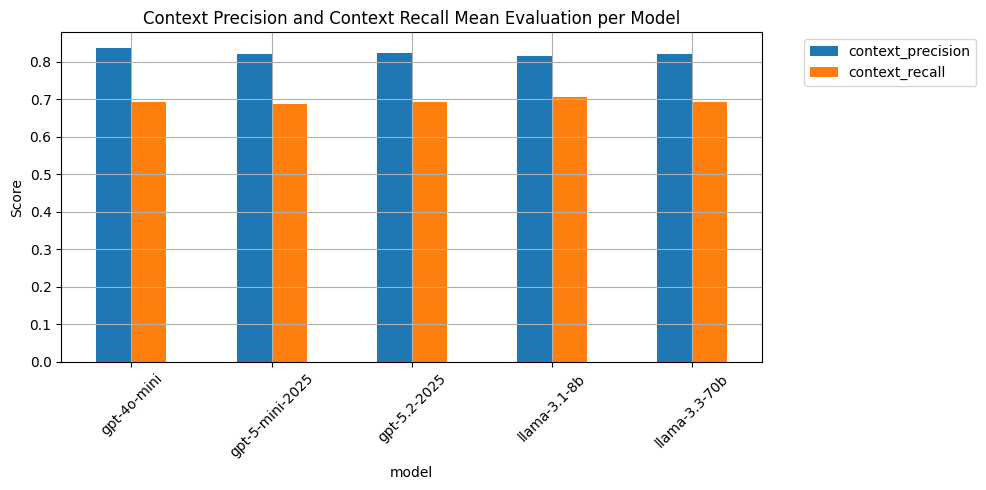

In [70]:
mean_pre_recall_metrics.set_index('model')[precision_recall_metrics].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Context Precision and Context Recall Mean Evaluation per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#### Boxplot – Distribution Across Runs

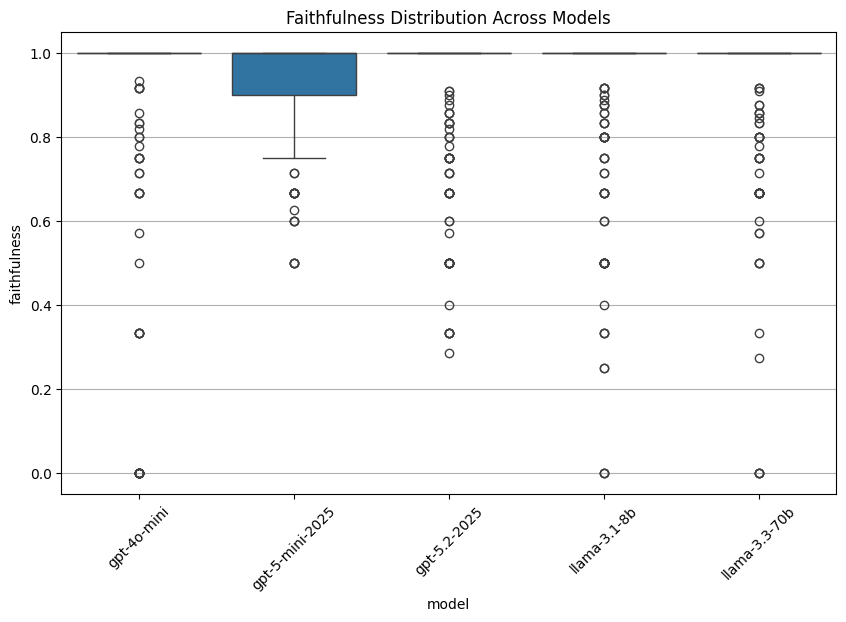

In [56]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x='model', y='faithfulness')
plt.title("Faithfulness Distribution Across Models")
plt.xticks(rotation=45)
plt.show()

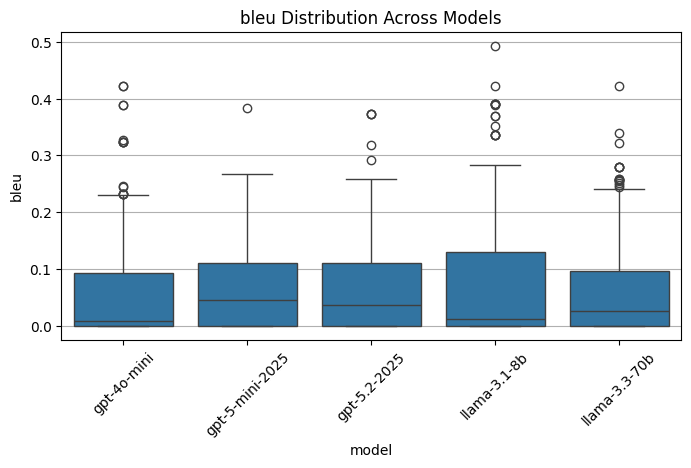

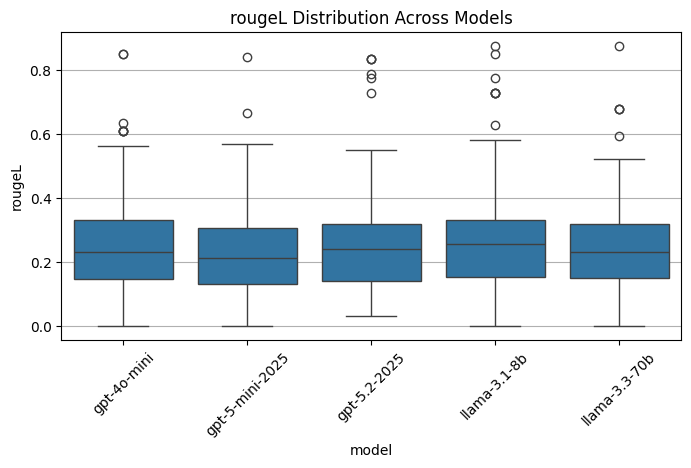

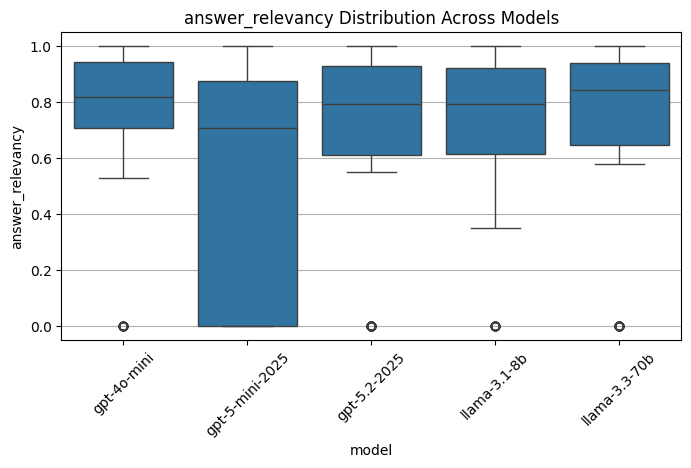

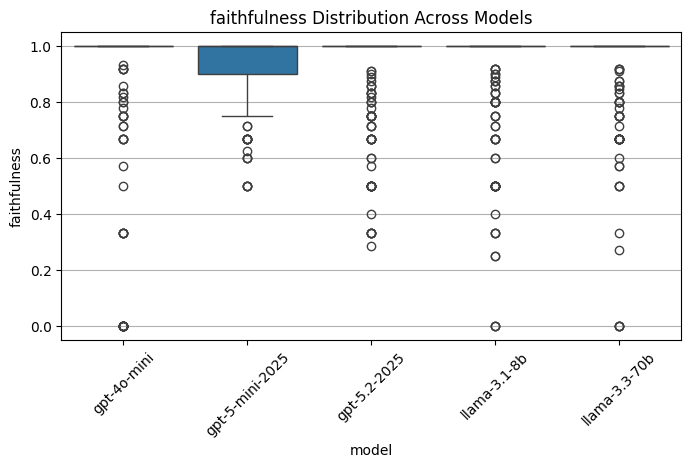

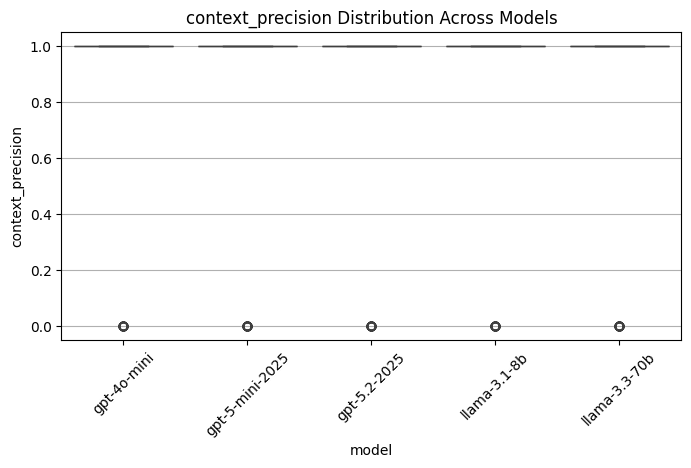

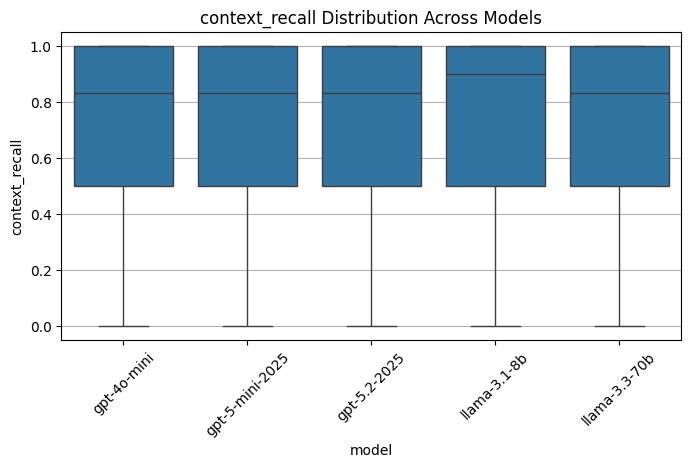

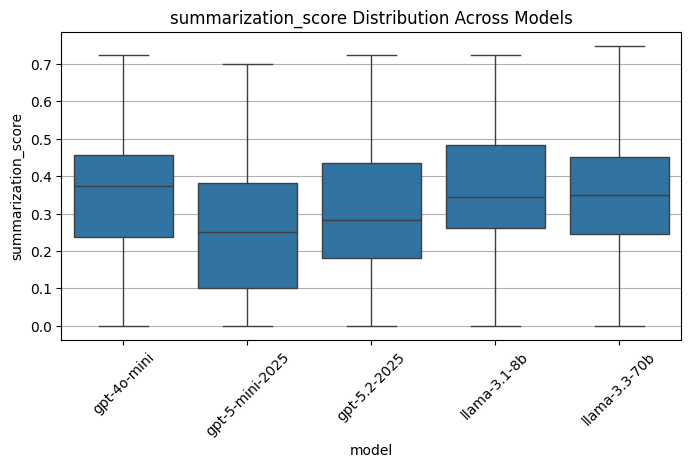

In [57]:
for metric in metrics:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_all, x='model', y=metric)
    plt.title(f"{metric} Distribution Across Models")
    plt.xticks(rotation=45)
    plt.show()

### Separate Retrieval vs Generation Metrics

#### Generation Metrics

In [58]:
generation_metrics = [
    'bleu',
    'rougeL',
    'answer_relevancy',
    'faithfulness',
    'summarization_score'
]

gen_mean = df_all.groupby('model')[generation_metrics].mean()
gen_mean

,bleu,rougeL,answer_relevancy,faithfulness,summarization_score
model,,,,,
gpt-4o-mini,0.063791,0.247988,0.747143,0.904612,0.359369
gpt-5-mini-2025,0.060065,0.224962,0.539998,0.937208,0.259432
gpt-5.2-2025,0.062272,0.251428,0.657659,0.925265,0.293285
llama-3.1-8b,0.076664,0.263179,0.713969,0.920827,0.361427
llama-3.3-70b,0.063541,0.241749,0.700869,0.933004,0.351481


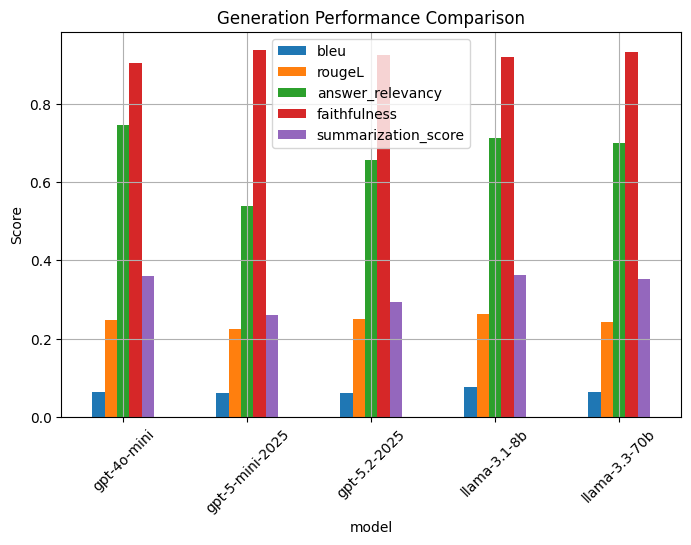

In [59]:
gen_mean.plot(kind='bar', figsize=(8,5))
plt.title("Generation Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#### Retrieval Metrics

In [60]:
retrieval_metrics = [
    'context_precision',
    'context_recall'
]

ret_mean = df_all.groupby('model')[retrieval_metrics].mean()
ret_mean

,context_precision,context_recall
model,,
gpt-4o-mini,0.836,0.691779
gpt-5-mini-2025,0.820,0.686311
gpt-5.2-2025,0.824,0.691843
llama-3.1-8b,0.816,0.705409
llama-3.3-70b,0.820,0.692003


#### Compare Retrieval Only

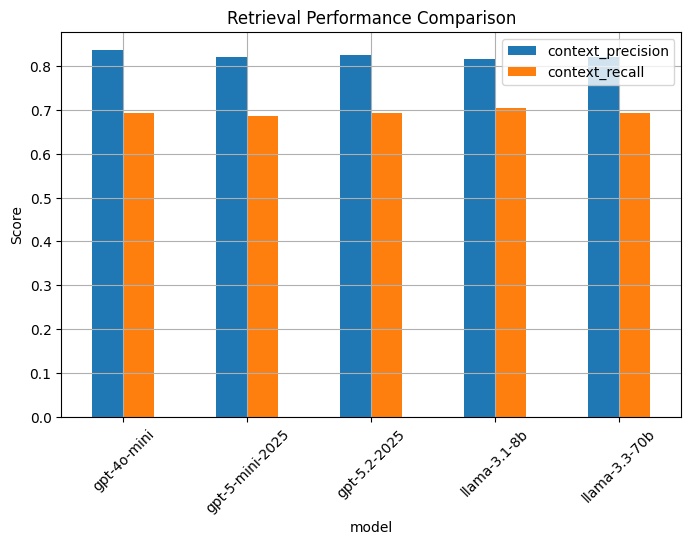

In [61]:
ret_mean.plot(kind='bar', figsize=(8,5))
plt.title("Retrieval Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()